In [262]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch
from torch import Tensor
from torch.nn import Linear
from torch.nn import Sigmoid, ReLU, BatchNorm1d, Dropout, Conv1d, MaxPool1d
from torch.nn import Module
from torch.optim import SGD, Adam
from torch.nn import MSELoss
from torch.nn.init import xavier_uniform_
%matplotlib inline

In [263]:
# Constants
PATH = './data/train_joined.csv'

In [264]:
brain = pd.read_csv(PATH)
brain['age']
print(brain.columns)


Index(['age', 'education', 'Female', 'Male', 'rel-1', 'rel-3', 'rel-4',
       'rel-5', 'rel-8', 'rel-13',
       ...
       'rel-3975', 'rel-3977', 'rel-3979', 'rel-3981', 'rel-3989', 'rel-3993',
       'rel-3997', 'rel-3999', 'rel-4001', 'rel-4003'],
      dtype='object', length=1206)


In [265]:
X = brain.drop('age', axis=1)  
y = brain['age']  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_test)

     education  Female  Male     rel-1     rel-3     rel-4     rel-5  \
40          17       0     1  0.121746  0.000000  0.155463  0.018013   
65           4       1     0  0.178511  0.000000  0.135681  0.000000   
4            9       1     0  0.161360  0.000000  0.172043  0.017686   
47          14       0     1  0.102923  0.000000  0.138054  0.000000   
42          13       1     0  0.119665  0.000000  0.139519  0.023175   
69           4       1     0  0.142276  0.000000  0.200000  0.010100   
26           9       0     1  0.178921  0.000000  0.177437  0.021839   
11          10       0     1  0.127077  0.000000  0.167238  0.020516   
10           9       1     0  0.150793  0.000000  0.145329  0.014428   
44           6       1     0  0.119662  0.000000  0.148933  0.000000   
73           7       1     0  0.238593  0.024272  0.237141  0.083822   
55           4       0     1  0.178360  0.000000  0.173335  0.048803   
68           4       0     1  0.133988  0.000000  0.194944  0.02

In [266]:
print(y_train)
print(y_train.shape)

66     57
90     69
62     55
22     24
85     66
       ..
106    74
14     16
92     76
51     25
102    71
Name: age, Length: 89, dtype: int64
(89,)


<Axes: xlabel='age', ylabel='count'>

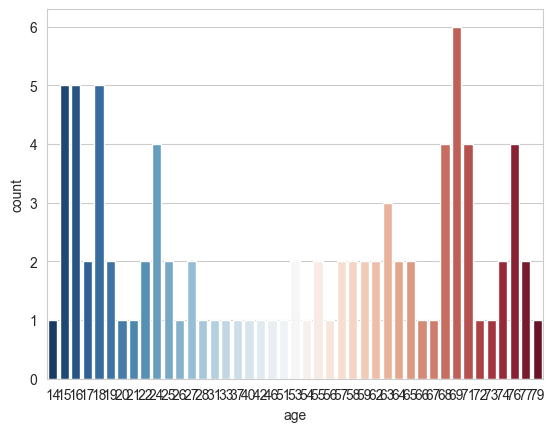

In [267]:
sns.set_style('whitegrid')
sns.countplot(x='age', data = pd.DataFrame(y_train,columns = ['age']), palette = 'RdBu_r')

In [268]:
cross_valid_model = SVC(random_state = 42)
scores = cross_val_score(cross_valid_model, X, y, cv = 2)
scores

c:\Users\ciara\anaconda3\envs\Monai\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


array([0.125     , 0.08928571])

In [269]:
model = SVC(random_state=42)
model.fit(X_train, y_train)

SVC(random_state=42)

In [270]:
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
predictions = model.predict(X_test)
print("%0.2f accuracy" % (accuracy_score(y_test, predictions)))
print(classification_report(y_test, predictions))
print(predictions)

c:\Users\ciara\anaconda3\envs\Monai\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.11 accuracy with a standard deviation of 0.02


ValueError: Expected 2D array, got 1D array instead:
array=[27. 62. 15. 20. 19. 70. 40. 16. 15. 41. 56. 61. 58. 55. 13. 16. 25. 51.
 58. 52. 24. 16. 25.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.